## Toy

In [2]:
import pandas as pd 
import numpy as np 
import os 
import sys 
from tqdm import tqdm
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

In [3]:
# read tables
dir_path = '/Users/zeshanmh/Documents/research/benchmarking-os/'
out   = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/outc_adj_bio.csv'))
std_trt = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/dem_ctos_bio.csv'))[['ID', 'HRTARM', 'OSFLAG']]
hyst    = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/f2_ctos_bio.csv'))[['ID','HYST']]
pre_hrt  = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/f43_ctos_bio.csv'))[['ID', 'TOTESTAT','TOTPSTAT']]
post_hrt = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/f48_av1_os_pub.csv'))[['ID','ELSTYR','PLSTYR','HRTCMBP']]
unc_hf   = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/unc_hf_bio.csv'))[['ID','CHDYRHX','CHDEVERHX','HYPERTNHX','MIHX','PVDHX','DIABHX','STROKEHX']]


/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3242597729.py:5: DtypeWarning: Columns (39,42,57,59,66) have mixed types. Specify dtype option on import or set low_memory=False.
  hyst    = pd.read_csv(os.path.join(dir_path, 'whi/data/data/main_study/csv/f2_ctos_bio.csv'))[['ID','HYST']]


In [4]:
# List of outcomes     
glbl_list = ['CHD', 'BREAST', 'STROKE', 'PE', 'ENDMTRL', 'COLORECTAL', 'BKHIP', 'DEATH']    
other_list = ['PTCA', 'DVT']

In [5]:
# construct os_df 
selection_flag = 'biased'
'''
drop_all_excluded: this drops all patients who had hysterectomy OR are on unopposed estrogen; thus, selection, S = 0 and S = 1, is based on censoring only
drop_some_excluded: this keeps patients who had hyseterectomy OR are on unopposed estrogen but were past users of combined HRT, assigns them to be S = 0;
censored patients are additionally S = 0
drop_no_excluded: keeps all patients who had hysterectomy OR are on unopposed estrogen, and assigns them S = 0; censored patients are additionally S = 0
'''
additional_selection_processing = 'drop_some_excluded' # 'drop_some_excluded', 'drop_no_excluded', 'drop_all_excluded'
'''
if censored_patients_sel0 = True, then censored patients are additionally S = 0
'''
censored_patients_sel0 = True 

os_df = std_trt.drop_duplicates('ID')
os_df = os_df[os_df['OSFLAG'] == 'Yes']
os_df = os_df.merge(hyst, on='ID', how='left')
os_df = os_df.merge(pre_hrt, on='ID', how='left')
print(os_df['TOTESTAT'].value_counts())
print(os_df['HYST'].value_counts())
os_df = os_df.merge(post_hrt, on='ID', how='left')
if additional_selection_processing == 'drop_some_excluded': 
    os_df = os_df.merge(unc_hf, on='ID', how='left')
    condition_dict = {
        'CHDEVERHX': ('!=', 1.),
        'HYPERTNHX': ('!=', 1.),
        'MIHX': ('!=', 1.),
        'PVDHX': ('!=', 1.),
        'DIABHX': ('!=', 1.),
        'STROKEHX': ('!=', 1.)
    }
    condition = (os_df['HYST'] == 'Yes') & ((os_df['TOTPSTAT'] == 'Never used') | (os_df['TOTPSTAT'] == 'Current user'))
    os_df = os_df[~condition]
    condition2 = (os_df['TOTESTAT'] == 'Current user') & ((os_df['TOTPSTAT'] == 'Never used') | (os_df['TOTPSTAT'] == 'Current user'))
    os_df = os_df[~condition2]
    os_df['S'] = os_df.apply(
        lambda row: 0 if (row['HYST'] == 'Yes' or row['TOTESTAT'] == 'Current user') else 1,
        axis=1
    )
elif additional_selection_processing == 'drop_no_excluded': 
    # Selected patients
    os_df['S'] = os_df.apply(
        lambda row: 1 if (row['HYST'] == 'No' and row['TOTESTAT'] in ['Never used', 'Past user']) else 0,
        axis=1
    )
elif additional_selection_processing == 'drop_all_excluded':
    os_df = os_df[os_df['HYST'] == 'No']
    os_df = os_df[os_df['TOTESTAT'].isin(['Never used', 'Past user'])]
    os_df['S'] = 1

os_df = os_df.merge(out, on='ID', how='left')

# 35551 (control) + 17503 (intervention) = 53054

print(os_df[os_df['TOTPSTAT'].isin(['Current user'])].shape)
print(os_df[os_df['TOTPSTAT'].isin(['Never used', 'Past user'])].shape)

if selection_flag == 'biased': 
    os_df = os_df[os_df['TOTPSTAT'].isin(['Never used', 'Past user','Current user'])]
    os_df['HRTARM'] = os_df['TOTPSTAT'].map({'Current user': 1, 'Never used': 0, 'Past user': 0})
elif selection_flag == 'unbiased' or selection_flag == 'manually_biased': 
    os_df = os_df[os_df['TOTPSTAT'].isin(['Never used', 'Past user','Current user'])]
    conditions = [
        (((os_df['ELSTYR'] == 'Yes') & (os_df['PLSTYR'] == 'Yes')) | (os_df['HRTCMBP'] == 'Yes')),
        ((os_df['ELSTYR'] == 'No') & (os_df['PLSTYR'] == 'No')),
        (((os_df['ELSTYR'] == 'Yes') & (os_df['PLSTYR'] == 'No')) | ((os_df['ELSTYR'] == 'No') & (os_df['PLSTYR'] == 'Yes')))
    ]
    choices = [1, 0, -1]
    os_df['HRTGRP'] = np.select(conditions, choices, default=-2)
    os_df = os_df[os_df['HRTGRP'] != -2]
    os_df['HRTARM'] = (os_df['HRTGRP'] == 1).astype(int)
    os_df['S'] = os_df.apply(lambda row: 0 if row['TOTPSTAT'] == 'Current user' else row['S'], axis=1)
os_df['OS'] = 1

# os_end_day = None
os_end_day = 6*365
os_df['END_DY'] = os_end_day if os_end_day is not None else os_df['ENDFOLLOWDY']
# os_df['END_DY'] = os_df.apply(lambda x: x['DEATHDY'] if x['DEATHDY'] < os_end_day else os_end_day, axis=1)


# Process outcomes (same as CT)
for i in glbl_list + other_list:
    os_df[i+'_E'] = ((os_df[i] == 1) & (os_df[i+'DY'] <= os_df['END_DY'])).astype(int)
    os_df[i+'_DY'] = np.where(os_df[i+'_E'] == 1, os_df[i+'DY'], os_df['END_DY'])
    os_df[i+'_EDY'] = np.where(os_df[i+'_E'] == 1, os_df[i+'_DY'], np.nan)

# Global index
os_df['GLBL_E'] = (os_df[[j+'_E' for j in glbl_list]].sum(axis=1) > 0).astype(int)
os_df['GLBL_DY'] = np.where(os_df['GLBL_E'] == 1,
                            os_df[[j+'_EDY' for j in glbl_list]].min(axis=1),
                            os_df[[j+'_DY' for j in glbl_list]].min(axis=1))

# Selection variable adjustment
for i in glbl_list + other_list:
    os_df['S_'+i] = os_df['S']
    if censored_patients_sel0: 
        os_df['S_'+i] = np.where(os_df[i+'DY'] > os_df['END_DY'], 0, os_df['S_'+i])
os_df['S_GLBL'] = os_df['S']

# Select needed columns
os_df = os_df[['ID', 'OS', 'HRTARM'] + 
                ['S_'+j for j in glbl_list + other_list + ['GLBL']] + 
                [j+'_E' for j in glbl_list + other_list + ['GLBL']] + 
                [j+'_DY' for j in glbl_list + other_list + ['GLBL']]]

os_df

TOTESTAT
Never used      58890
Current user    23290
Past user       11432
Name: count, dtype: int64
HYST
No     54440
Yes    39149
Name: count, dtype: int64
(17571, 370)
(39130, 370)


,ID,OS,HRTARM,S_CHD,S_BREAST,S_STROKE,S_PE,S_ENDMTRL,S_COLORECTAL,S_BKHIP,...,BREAST_DY,STROKE_DY,PE_DY,ENDMTRL_DY,COLORECTAL_DY,BKHIP_DY,DEATH_DY,PTCA_DY,DVT_DY,GLBL_DY
0,591800,1,0,1,1,1,1,0,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
1,548198,1,0,1,1,1,1,1,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
2,670866,1,1,1,1,1,1,1,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
3,665473,1,1,1,1,1,1,1,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
4,508135,1,0,1,1,1,1,1,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56729,641028,1,0,1,1,1,1,0,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
56730,687963,1,0,1,1,1,1,1,1,1,...,203.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,203.0
56731,681994,1,1,1,1,1,1,1,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0
56732,575472,1,0,1,1,1,1,1,1,1,...,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0,2190.0


In [6]:
if selection_flag == 'manually_biased': 
    # removing age and menopausal status
    categorical_features = {
        'dem_ctos_bio.csv': {'ETHNIC': True, 'EDUC': True}, 
        'f80_ctos_bio.csv': {'BMI': False}, 
        'f34_ctos_bio.csv': {'SMOKING': True}, 
        'f151_ctos_bio.csv': {'PHYSFUN': False}    
    }
    
    new_feature_dict = { 
        'dem_ctos_bio.csv': ['ETHNIC_White', \
                             'EDUC_Some post-graduate or professional', \
                             'EDUC_Some college or Associate Degree'],
        'f80_ctos_bio.csv': ['BMI'],
        'f34_ctos_bio.csv': ['SMOKING_Past Smoker', 'SMOKING_Current Smoker'],
        'f151_ctos_bio.csv': ['PHYSFUN']
    }
else:
    categorical_features = {
        'dem_ctos_bio.csv': {'AGE': False, 'ETHNIC': True, 'EDUC': True}, 
        'f80_ctos_bio.csv': {'BMI': False}, 
        'f34_ctos_bio.csv': {'SMOKING': True}, 
        'f31_ctos_bio.csv': {'MENO': False}, 
        'f151_ctos_bio.csv': {'PHYSFUN': False}    
    }
    
    new_feature_dict = { 
        'dem_ctos_bio.csv': ['AGE', 'ETHNIC_White', \
                             'EDUC_Some post-graduate or professional', \
                             'EDUC_Some college or Associate Degree'],
        'f80_ctos_bio.csv': ['BMI'],
        'f34_ctos_bio.csv': ['SMOKING_Past Smoker', 'SMOKING_Current Smoker'],
        'f31_ctos_bio.csv': ['MENO'],
        'f151_ctos_bio.csv': ['PHYSFUN']
    }
    

In [7]:
import pandas.api.types as ptypes

ctos_temp = os_df.copy()
# Dictionary to specify which features are categorical

# dfs = []  # Store all dataframes to concatenate later
new_dir_path = dir_path + 'whi/data/data/main_study/csv'

for filename, f_dict in categorical_features.items():
    # Read the data
    df = pd.read_csv(os.path.join(new_dir_path, filename))
    if filename == 'f80_ctos_bio.csv': 
        df = df.query('F80VTYP == "Screening"')
    elif filename == 'f151_ctos_bio.csv': 
        idx = df.groupby('ID')['F151DAYS'].idxmin().reset_index(drop=True)
        df = df.loc[idx, :].reset_index(drop=True)[['ID','PHYSFUN']]
    # Select needed columns
    features = list(f_dict.keys())
    df = df[['ID'] + features]
    
    # Separate ID column
    id_col = df['ID']
    print(f"Processed {filename}")
    print(df.shape)

    orig_cols = ctos_temp.columns.tolist()
    ctos_temp = ctos_temp.merge(df, on='ID', how='left')

    # Handle continuous and categorical features separately
    cont_features = [f for f in features if not f_dict[f]]
    cat_features = [f for f in features if f_dict[f]]
    
    # Handle continuous features
    if cont_features:
        cont_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
        ctos_temp[cont_features] = cont_imputer.fit_transform(ctos_temp[cont_features])
    
    # Handle categorical features
    if cat_features:
        cat_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ctos_temp[cat_features] = cat_imputer.fit_transform(ctos_temp[cat_features])
        
        # One-hot encode categorical features
        ctos_temp = pd.get_dummies(ctos_temp, columns=cat_features, prefix=cat_features)

    if filename == 'dem_ctos_bio.csv': 
        ctos_temp = ctos_temp.rename(columns={'ETHNIC_White (not of Hispanic origin)': 'ETHNIC_White'})

    ctos_temp = ctos_temp[orig_cols + new_feature_dict[filename]]

ctos_temp = ctos_temp.astype({col: int for col in ctos_temp.select_dtypes(include='bool').columns})
display(ctos_temp)    


Processed dem_ctos_bio.csv
(161808, 4)
Processed f80_ctos_bio.csv
(161771, 2)
Processed f34_ctos_bio.csv
(161625, 2)


/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/1631860330.py:11: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(new_dir_path, filename))


Processed f31_ctos_bio.csv
(161705, 2)
Processed f151_ctos_bio.csv
(113491, 2)


,ID,OS,HRTARM,S_CHD,S_BREAST,S_STROKE,S_PE,S_ENDMTRL,S_COLORECTAL,S_BKHIP,...,GLBL_DY,AGE,ETHNIC_White,EDUC_Some post-graduate or professional,EDUC_Some college or Associate Degree,BMI,SMOKING_Past Smoker,SMOKING_Current Smoker,MENO,PHYSFUN
0,591800,1,0,1,1,1,1,0,1,1,...,2190.0,54.0,1,1,0,37.24671,0,0,44.0,80.000000
1,548198,1,0,1,1,1,1,1,1,1,...,2190.0,62.0,1,0,0,25.23429,1,0,51.0,78.366057
2,670866,1,1,1,1,1,1,1,1,1,...,2190.0,53.0,1,0,0,19.67392,1,0,45.0,78.366057
3,665473,1,1,1,1,1,1,1,1,1,...,2190.0,51.0,0,0,0,30.08313,1,0,49.0,78.366057
4,508135,1,0,1,1,1,1,1,1,1,...,2190.0,69.0,1,0,1,22.87513,0,0,51.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56696,641028,1,0,1,1,1,1,0,1,1,...,2190.0,69.0,1,1,0,25.50301,0,0,54.0,90.000000
56697,687963,1,0,1,1,1,1,1,1,1,...,203.0,70.0,1,0,1,23.11101,1,0,55.0,60.000000
56698,681994,1,1,1,1,1,1,1,1,1,...,2190.0,53.0,1,0,0,26.76123,0,0,48.0,95.000000
56699,575472,1,0,1,1,1,1,1,1,1,...,2190.0,75.0,1,0,0,28.07091,1,0,50.0,78.366057


In [8]:
from sklearn.model_selection import train_test_split 

df_os = ctos_temp.copy()
if selection_flag == 'manually_biased': 
    predictors = ['ETHNIC_White', 'EDUC_Some post-graduate or professional', 
          'EDUC_Some college or Associate Degree', 'BMI', 'SMOKING_Past Smoker', 
          'SMOKING_Current Smoker', 'PHYSFUN'] 
else: 
    predictors = ['AGE', 'ETHNIC_White', 'EDUC_Some post-graduate or professional', 
          'EDUC_Some college or Associate Degree', 'BMI', 'SMOKING_Past Smoker', 
          'SMOKING_Current Smoker', 'MENO', 'PHYSFUN'] 
outcome_name = 'CHD' # STROKE, BREAST

outcome= outcome_name + '_E'
trt    = 'HRTARM'
select = f'S_{outcome_name}'

drop_columns = [x for x in df_os.columns if x not in predictors + [outcome, trt, 'ID', 'S']]
df_os.rename(columns={trt: 'A', outcome: 'Y'}, inplace=True) 
df_os['S']  = df_os[select]
df_os['Y0'] = df_os['Y']
df_os['Y1'] = df_os['Y']
df_os['R'] = 1 - df_os['OS']
df_os.drop(columns=drop_columns, inplace=True)


In [9]:
display(df_os)

,ID,A,Y,AGE,ETHNIC_White,EDUC_Some post-graduate or professional,EDUC_Some college or Associate Degree,BMI,SMOKING_Past Smoker,SMOKING_Current Smoker,MENO,PHYSFUN,S,Y0,Y1,R
0,591800,0,0,54.0,1,1,0,37.24671,0,0,44.0,80.000000,1,0,0,0
1,548198,0,0,62.0,1,0,0,25.23429,1,0,51.0,78.366057,1,0,0,0
2,670866,1,0,53.0,1,0,0,19.67392,1,0,45.0,78.366057,1,0,0,0
3,665473,1,0,51.0,0,0,0,30.08313,1,0,49.0,78.366057,1,0,0,0
4,508135,0,0,69.0,1,0,1,22.87513,0,0,51.0,100.000000,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56696,641028,0,0,69.0,1,1,0,25.50301,0,0,54.0,90.000000,1,0,0,0
56697,687963,0,0,70.0,1,0,1,23.11101,1,0,55.0,60.000000,1,0,0,0
56698,681994,1,0,53.0,1,0,0,26.76123,0,0,48.0,95.000000,1,0,0,0
56699,575472,0,0,75.0,1,0,0,28.07091,1,0,50.0,78.366057,1,0,0,0


In [29]:
df_os_S1 = df_os.query('S == 1')
print(df_os_S1.columns)
print(df_os_S1['MENO'])
print(df_os_S1.query('MENO == 1.').shape)

Index(['ID', 'A', 'Y', 'AGE', 'ETHNIC_White',
       'EDUC_Some post-graduate or professional',
       'EDUC_Some college or Associate Degree', 'BMI', 'SMOKING_Past Smoker',
       'SMOKING_Current Smoker', 'MENO', 'PHYSFUN', 'S', 'Y0', 'Y1', 'R'],
      dtype='object')
0        44.0
1        51.0
2        45.0
3        49.0
4        51.0
         ... 
56696    54.0
56697    55.0
56698    48.0
56699    50.0
56700    57.0
Name: MENO, Length: 51824, dtype: float64
(0, 16)


/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3949628716.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup1'] = (df_os_S1['AGE'] >= 65)  # Older women (higher CVD risk)
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3949628716.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup2'] = ((df_os_S1['SMOKING_Past Smoker'] == 1) |
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3949628716.py:14: SettingWithCopyWarning: 


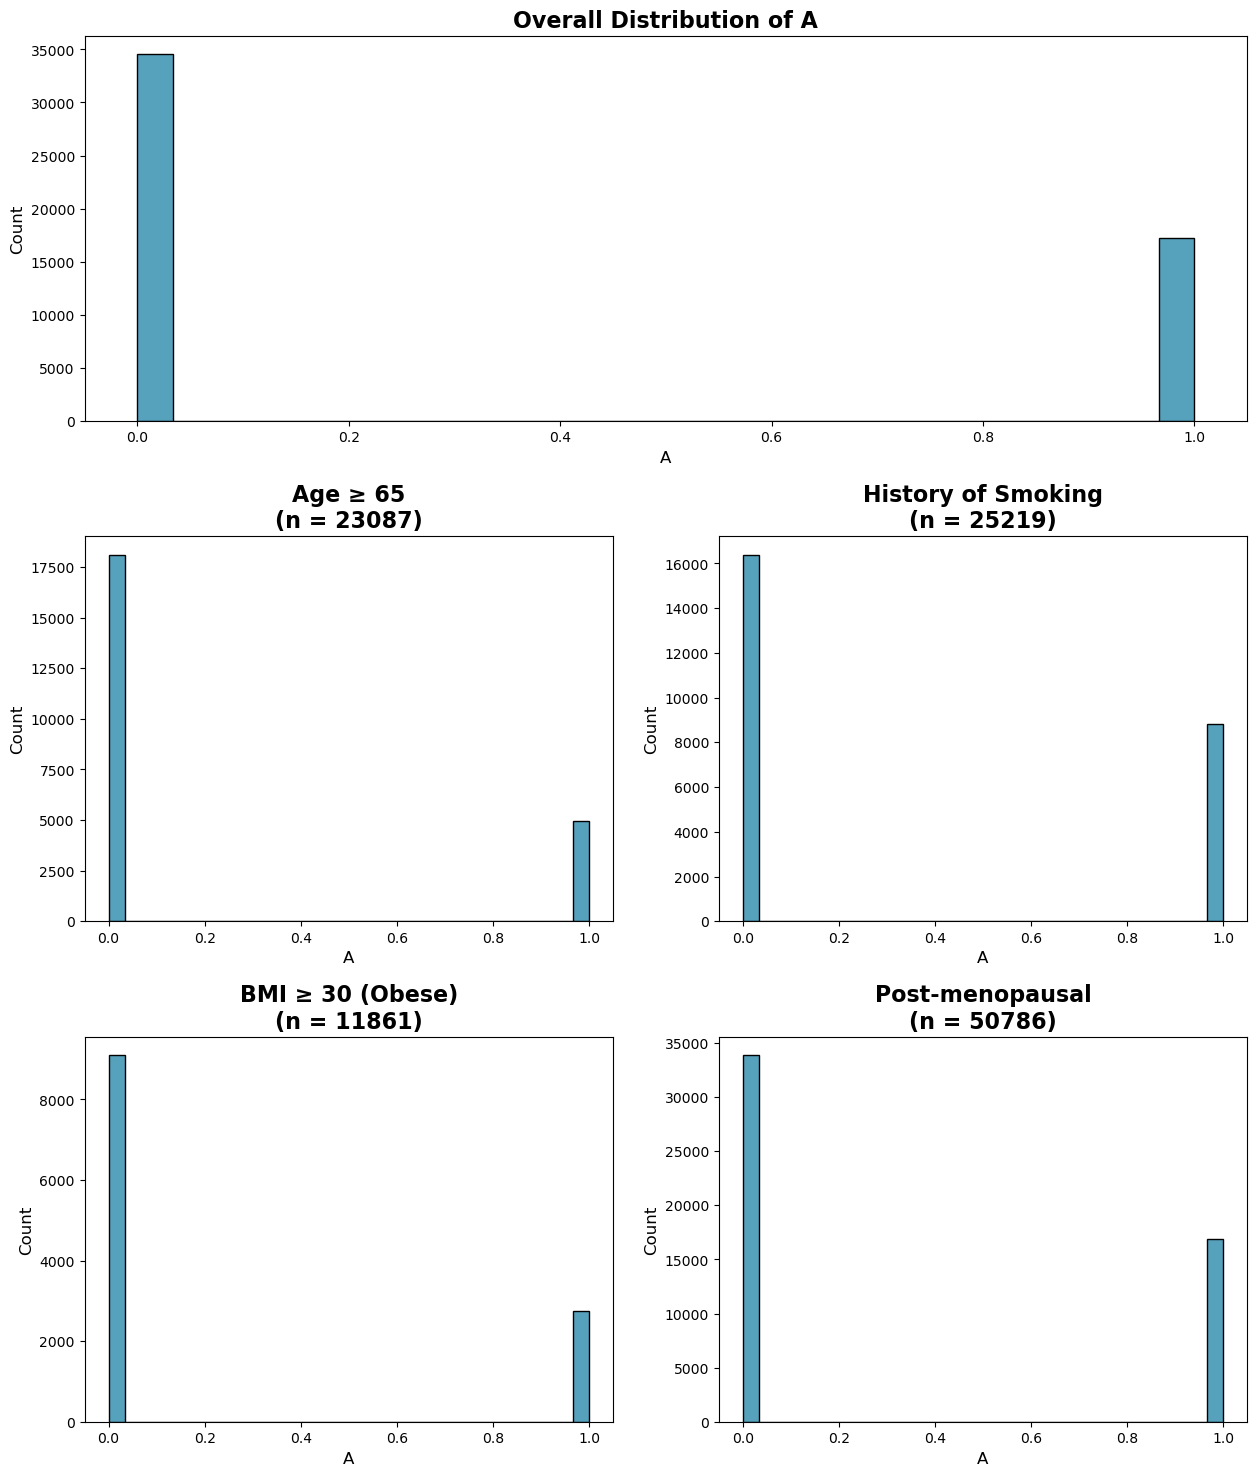

Subgroup 1: n = 23087 (44.5%)
Subgroup 2: n = 25219 (48.7%)
Subgroup 3: n = 11861 (22.9%)
Subgroup 4: n = 50786 (98.0%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

column = 'Y'

# Create simpler, single-condition subgroups
df_os_S1['subgroup1'] = (df_os_S1['AGE'] >= 65)  # Older women (higher CVD risk)

df_os_S1['subgroup2'] = ((df_os_S1['SMOKING_Past Smoker'] == 1) | 
                         (df_os_S1['SMOKING_Current Smoker'] == 1))  # Any smoking history (CVD risk)

df_os_S1['subgroup3'] = (df_os_S1['BMI'] >= 30)  # Obese (higher CVD and cancer risk)

df_os_S1['subgroup4'] = (df_os_S1['MENO'] < df_os_S1['AGE'])  # Post-menopausal (key factor for HRT)

# Set up the plot style
# plt.style.use('seaborn')
fig = plt.figure(figsize=(15, 18))

# Create subplots
gs = fig.add_gridspec(3, 2, hspace=0.3)

# Overall histogram
ax0 = fig.add_subplot(gs[0, :])
sns.histplot(data=df_os_S1, x=column, bins=30, color='#0f7ba2', alpha=0.7, ax=ax0)
ax0.set_title(f'Overall Distribution of {column}', fontsize=16, fontweight='bold')
ax0.set_xlabel(f'{column}', fontsize=12)
ax0.set_ylabel('Count', fontsize=12)

# Subgroup histograms
titles = ['Age ≥ 65',
          'History of Smoking',
          'BMI ≥ 30 (Obese)',
          'Post-menopausal']

for i, (subgroup, title) in enumerate(zip(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 
                                        titles)):
    row = (i // 2) + 1
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    
    # Get subset of data
    subset = df_os_S1[df_os_S1[subgroup] == 1]
    n_subset = len(subset)
    
    # Create histogram
    sns.histplot(data=subset, x=column, bins=30, color='#0f7ba2', alpha=0.7, ax=ax)
    ax.set_title(f'{title}\n(n = {n_subset})', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'{column}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

# Adjust layout and save
plt.tight_layout()
# plt.savefig('stratified_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Print subgroup sizes
for i, subgroup in enumerate(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 1):
    n = df_os_S1[subgroup].sum()
    print(f'Subgroup {i}: n = {n} ({n/len(df_os_S1)*100:.1f}%)')

/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/4231408320.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup1'] = ((df_os_S1['AGE'] >= 65) &
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/4231408320.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup2'] = ((df_os_S1['AGE'] < 65) &
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/4231408320.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

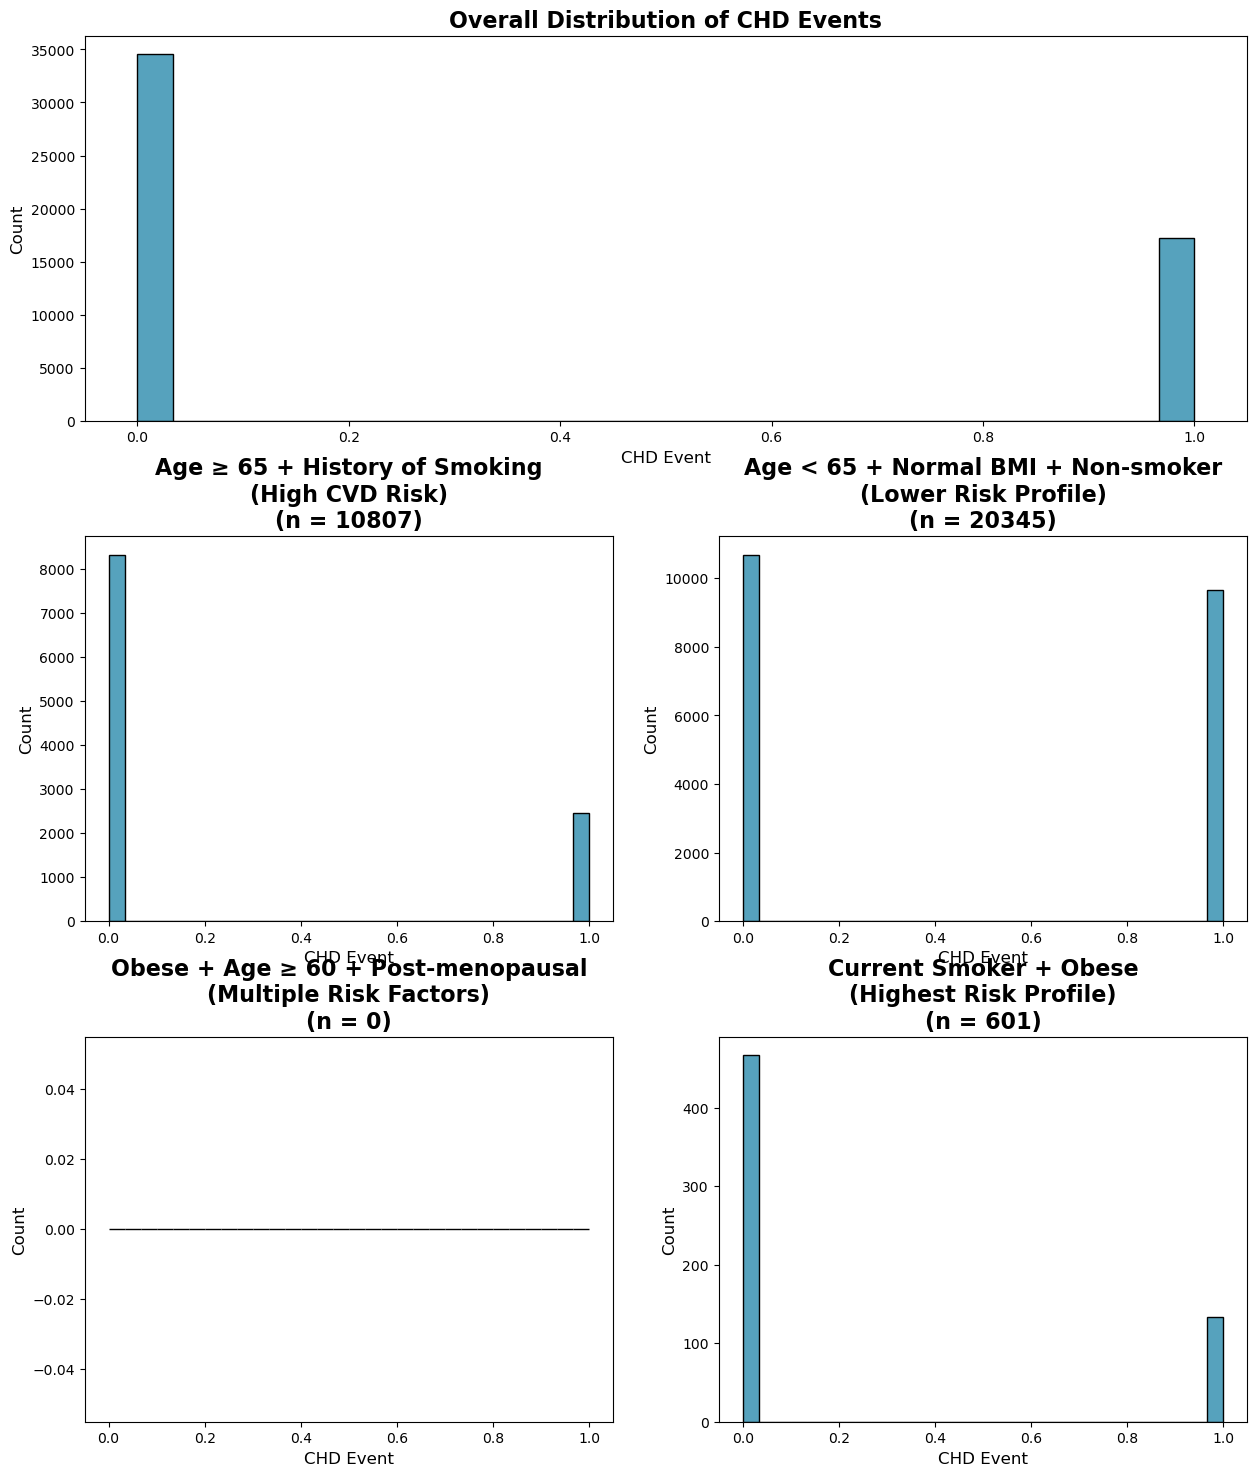

Subgroup 1: n = 10807 (20.9%)
Subgroup 2: n = 20345 (39.3%)
Subgroup 3: n = 0 (0.0%)
Subgroup 4: n = 601 (1.2%)


In [ ]:
import matplotlib.pyplot as plt                            
import seaborn as sns
import numpy as np
import pandas as pd

# Create more complex, clinically relevant subgroups
df_os_S1['subgroup1'] = ((df_os_S1['AGE'] >= 65) & 
                         ((df_os_S1['SMOKING_Past Smoker'] == 1) | 
                          (df_os_S1['SMOKING_Current Smoker'] == 1)))  # Older smokers (highest CVD risk)

df_os_S1['subgroup2'] = ((df_os_S1['AGE'] < 65) & 
                         (df_os_S1['BMI'] < 30) &
                         (df_os_S1['SMOKING_Current Smoker'] == 0))  # Lower risk younger women

df_os_S1['subgroup3'] = ((df_os_S1['BMI'] >= 30) & 
                         (df_os_S1['AGE'] >= 60) &
                         (df_os_S1['MENO'] == 1))  # Older obese post-menopausal (multiple risks)

df_os_S1['subgroup4'] = ((df_os_S1['SMOKING_Current Smoker'] == 1) & 
                         (df_os_S1['BMI'] >= 30))  # Current smokers with obesity (highest risk)

# Set up the plot style
# plt.style.use('seaborn')
fig = plt.figure(figsize=(15, 18))

# Create subplots
gs = fig.add_gridspec(3, 2, hspace=0.3)

# Overall histogram
ax0 = fig.add_subplot(gs[0, :])
sns.histplot(data=df_os_S1, x='A', bins=30, color='#0f7ba2', alpha=0.7, ax=ax0)
ax0.set_title('Overall Distribution of CHD Events', fontsize=16, fontweight='bold')
ax0.set_xlabel('CHD Event', fontsize=12)
ax0.set_ylabel('Count', fontsize=12)

# Subgroup histograms
titles = ['Age ≥ 65 + History of Smoking\n(High CVD Risk)',
          'Age < 65 + Normal BMI + Non-smoker\n(Lower Risk Profile)',
          'Obese + Age ≥ 60 + Post-menopausal\n(Multiple Risk Factors)',
          'Current Smoker + Obese\n(Highest Risk Profile)']

for i, (subgroup, title) in enumerate(zip(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 
                                        titles)):
    row = (i // 2) + 1
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    
    # Get subset of data
    subset = df_os_S1[df_os_S1[subgroup] == 1]
    n_subset = len(subset)
    
    # Create histogram
    sns.histplot(data=subset, x='A', bins=30, color='#0f7ba2', alpha=0.7, ax=ax)
    ax.set_title(f'{title}\n(n = {n_subset})', fontsize=16, fontweight='bold')
    ax.set_xlabel('CHD Event', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

# Adjust layout and save
plt.tight_layout()
# plt.savefig('stratified_histograms_complex.png', dpi=300, bbox_inches='tight')
plt.show()

# Print subgroup sizes and check overlap
for i, subgroup in enumerate(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 1):
    n = df_os_S1[subgroup].sum()
    print(f'Subgroup {i}: n = {n} ({n/len(df_os_S1)*100:.1f}%)')

/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/714831557.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup1'] = ((df_os_S1['AGE'] < 60) &
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/714831557.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup2'] = ((df_os_S1['AGE'] < 60) &
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/714831557.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

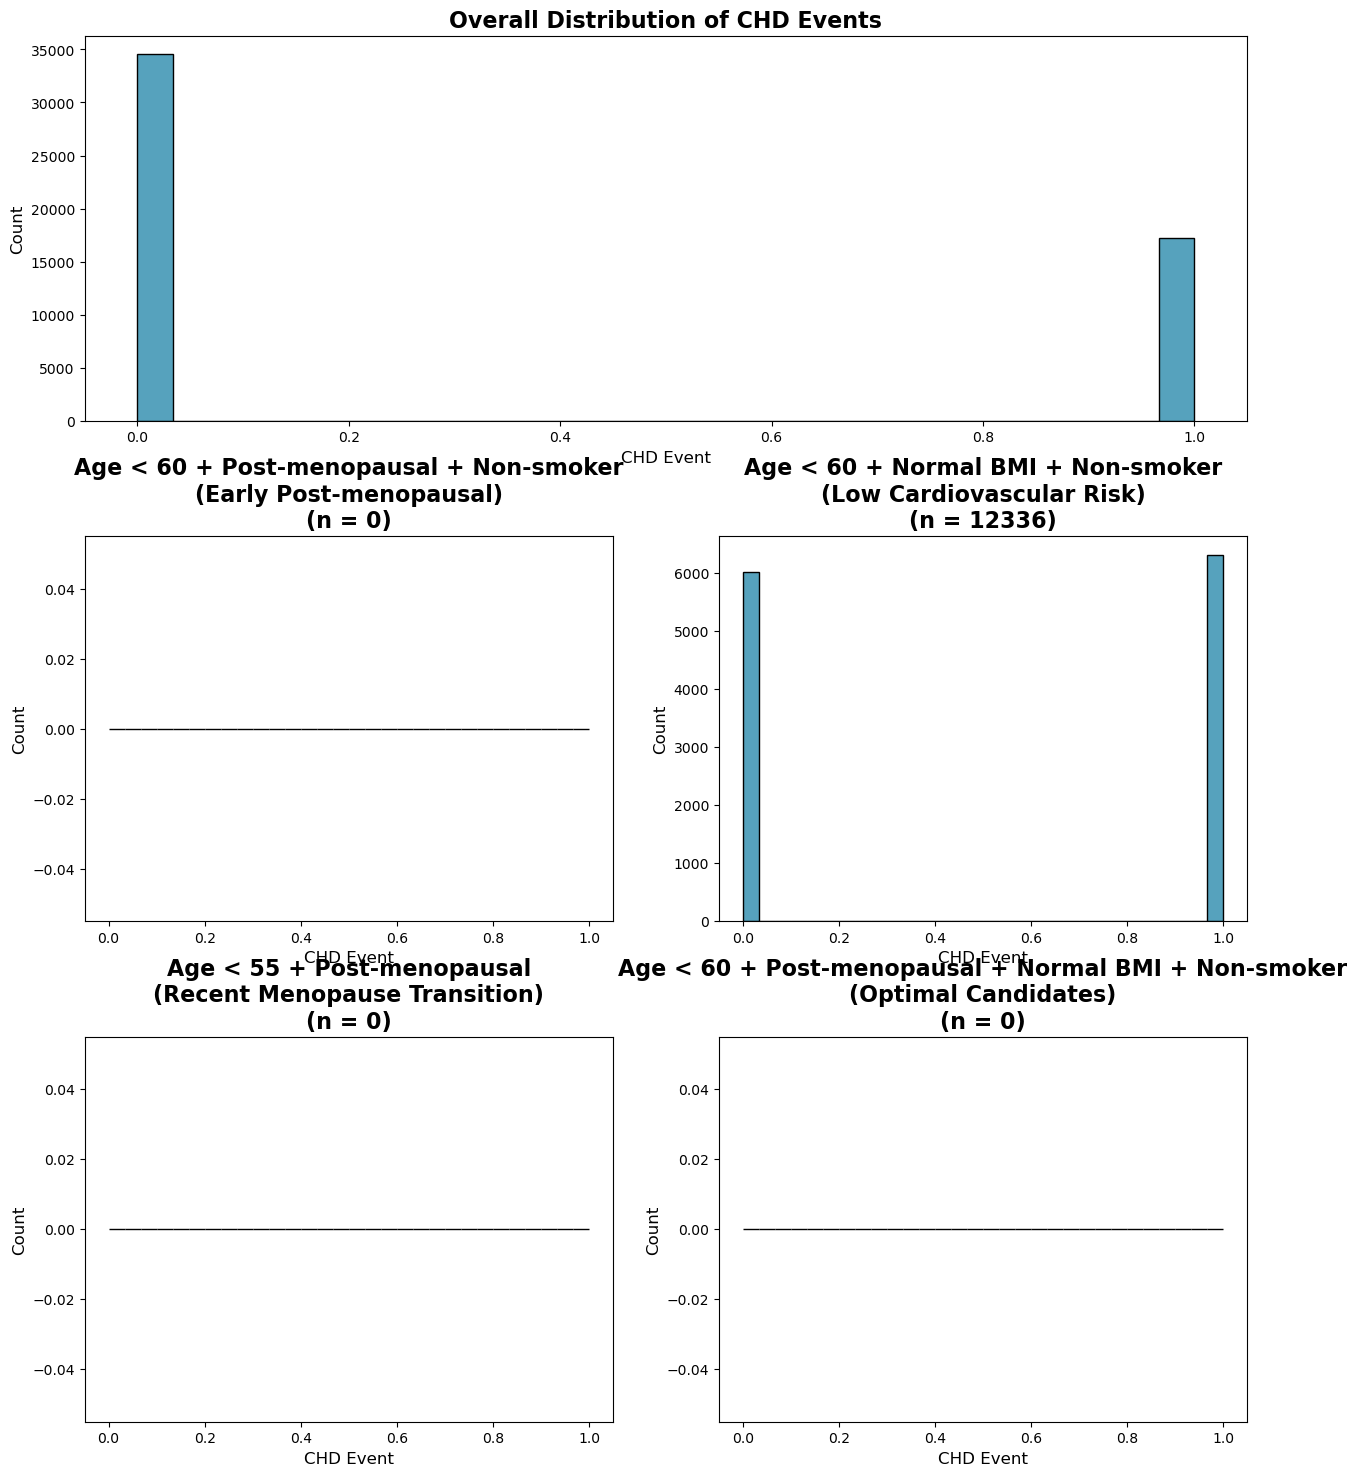

Subgroup 1: n = 0 (0.0%)
Subgroup 2: n = 12336 (23.8%)
Subgroup 3: n = 0 (0.0%)
Subgroup 4: n = 0 (0.0%)


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create subgroups where HRT might be more beneficial
df_os_S1['subgroup1'] = ((df_os_S1['AGE'] < 60) & 
                         (df_os_S1['MENO'] == 1) &
                         (df_os_S1['SMOKING_Current Smoker'] == 0))  # Younger post-menopausal non-smokers

df_os_S1['subgroup2'] = ((df_os_S1['AGE'] < 60) & 
                         (df_os_S1['BMI'] < 30) &
                         (df_os_S1['SMOKING_Current Smoker'] == 0))  # Younger, non-obese, non-smokers

df_os_S1['subgroup3'] = ((df_os_S1['AGE'] < 55) & 
                         (df_os_S1['MENO'] == 1))  # Recently post-menopausal

df_os_S1['subgroup4'] = ((df_os_S1['AGE'] < 60) & 
                         (df_os_S1['MENO'] == 1) &
                         (df_os_S1['BMI'] < 30) &
                         (df_os_S1['SMOKING_Current Smoker'] == 0))  # Optimal candidates

# Set up the plot style
# plt.style.use('seaborn')
fig = plt.figure(figsize=(15, 18))

# Create subplots
gs = fig.add_gridspec(3, 2, hspace=0.3)

# Overall histogram
ax0 = fig.add_subplot(gs[0, :])
sns.histplot(data=df_os_S1, x='A', bins=30, color='#0f7ba2', alpha=0.7, ax=ax0)
ax0.set_title('Overall Distribution of CHD Events', fontsize=16, fontweight='bold')
ax0.set_xlabel('CHD Event', fontsize=12)
ax0.set_ylabel('Count', fontsize=12)

# Subgroup histograms
titles = ['Age < 60 + Post-menopausal + Non-smoker\n(Early Post-menopausal)',
          'Age < 60 + Normal BMI + Non-smoker\n(Low Cardiovascular Risk)',
          'Age < 55 + Post-menopausal\n(Recent Menopause Transition)',
          'Age < 60 + Post-menopausal + Normal BMI + Non-smoker\n(Optimal Candidates)']

for i, (subgroup, title) in enumerate(zip(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 
                                        titles)):
    row = (i // 2) + 1
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    
    # Get subset of data
    subset = df_os_S1[df_os_S1[subgroup] == 1]
    n_subset = len(subset)
    
    # Create histogram
    sns.histplot(data=subset, x='A', bins=30, color='#0f7ba2', alpha=0.7, ax=ax)
    ax.set_title(f'{title}\n(n = {n_subset})', fontsize=16, fontweight='bold')
    ax.set_xlabel('CHD Event', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

# Adjust layout and save
plt.tight_layout()
plt.savefig('stratified_histograms_favorable.png', dpi=300, bbox_inches='tight')
plt.show()

# Print subgroup sizes
for i, subgroup in enumerate(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 1):
    n = df_os_S1[subgroup].sum()
    print(f'Subgroup {i}: n = {n} ({n/len(df_os_S1)*100:.1f}%)')

/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3075028480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup1'] = ((df_os_S1['AGE'] >= 70) &
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3075028480.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_os_S1['subgroup2'] = ((df_os_S1['SMOKING_Current Smoker'] == 1) &
/var/folders/t9/9775q6dn21l67f71h7t7xj0h0000gn/T/ipykernel_38449/3075028480.py:13: SettingWithCopyWarning: 
A value is trying to be set

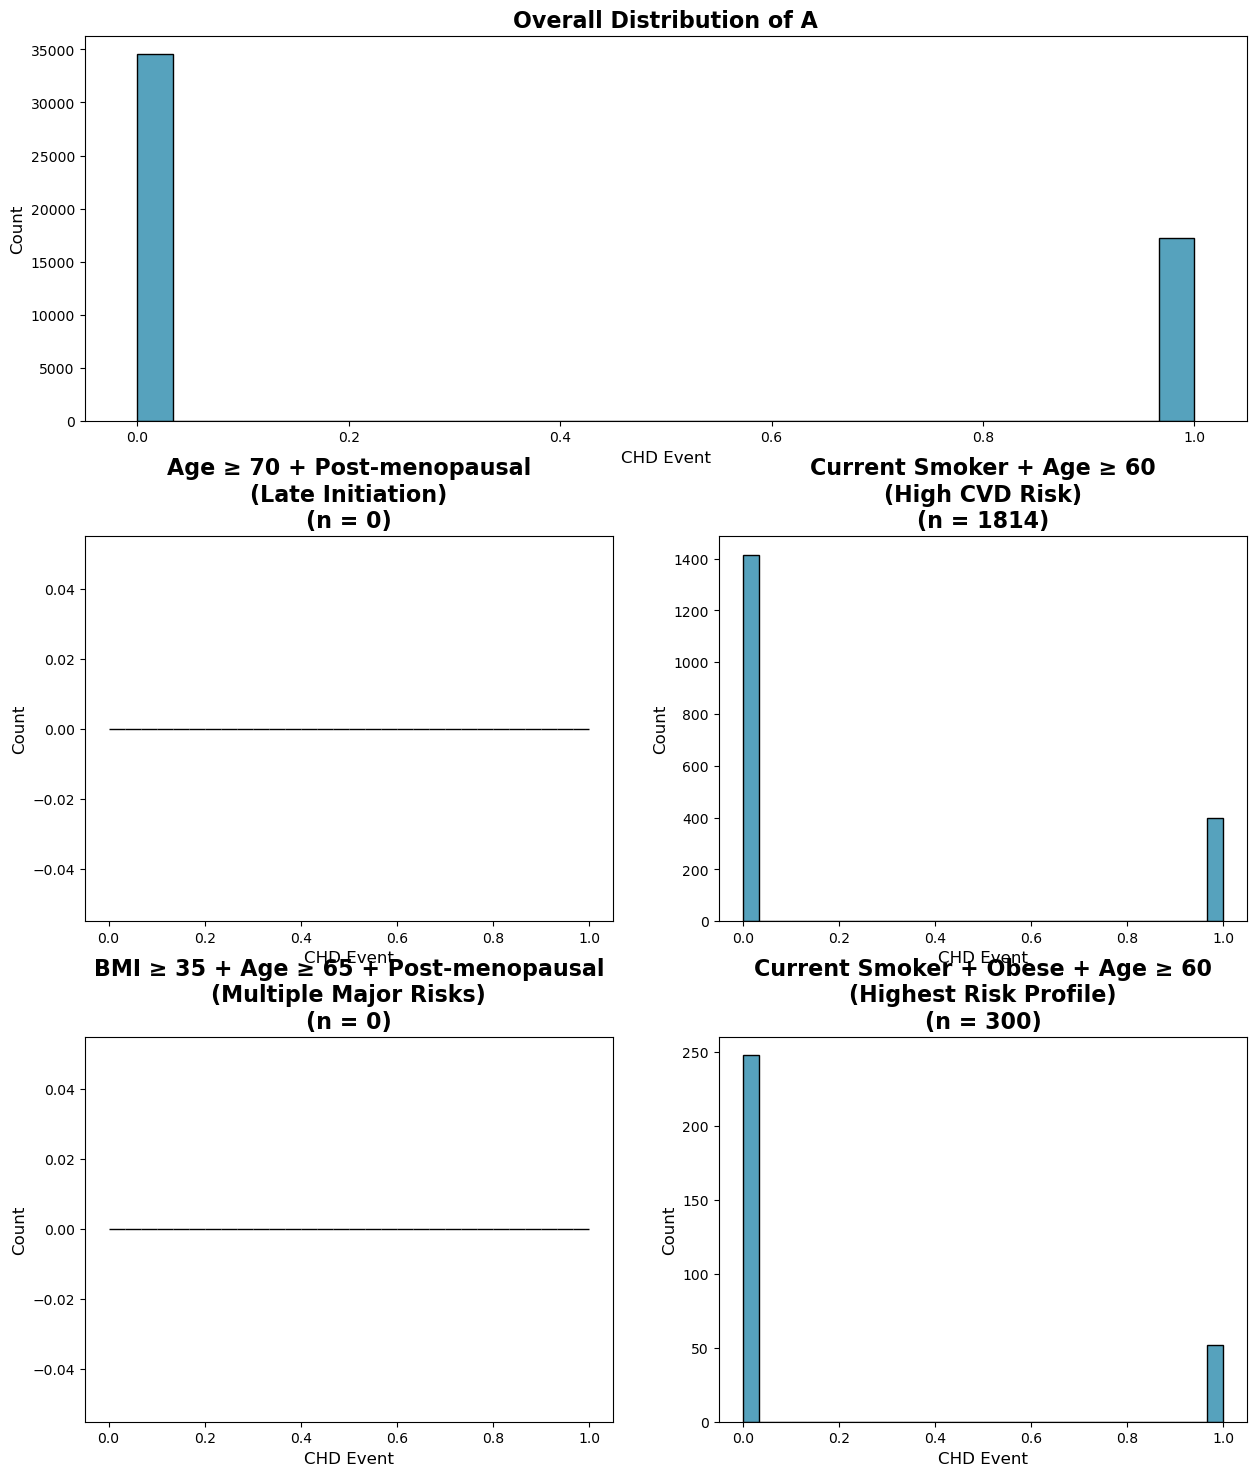

Subgroup 1: n = 0 (0.0%)
Subgroup 2: n = 1814 (3.5%)
Subgroup 3: n = 0 (0.0%)
Subgroup 4: n = 300 (0.6%)


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create subgroups where HRT is likely contraindicated
df_os_S1['subgroup1'] = ((df_os_S1['AGE'] >= 70) & 
                         (df_os_S1['MENO'] == 1))  # Much older post-menopausal women

df_os_S1['subgroup2'] = ((df_os_S1['SMOKING_Current Smoker'] == 1) & 
                         (df_os_S1['AGE'] >= 60))  # Older current smokers

df_os_S1['subgroup3'] = ((df_os_S1['BMI'] >= 35) & 
                         (df_os_S1['AGE'] >= 65) &
                         (df_os_S1['MENO'] == 1))  # Older, severely obese, post-menopausal

df_os_S1['subgroup4'] = ((df_os_S1['SMOKING_Current Smoker'] == 1) & 
                         (df_os_S1['BMI'] >= 30) &
                         (df_os_S1['AGE'] >= 60))  # Older, obese smokers (multiple major risks)

# Set up the plot style
# plt.style.use('seaborn')
fig = plt.figure(figsize=(15, 18))

# Create subplots
gs = fig.add_gridspec(3, 2, hspace=0.3)

# Overall histogram
ax0 = fig.add_subplot(gs[0, :])
sns.histplot(data=df_os_S1, x='A', bins=30, color='#0f7ba2', alpha=0.7, ax=ax0)
ax0.set_title('Overall Distribution of A', fontsize=16, fontweight='bold')
ax0.set_xlabel('CHD Event', fontsize=12)
ax0.set_ylabel('Count', fontsize=12)

# Subgroup histograms
titles = ['Age ≥ 70 + Post-menopausal\n(Late Initiation)',
          'Current Smoker + Age ≥ 60\n(High CVD Risk)',
          'BMI ≥ 35 + Age ≥ 65 + Post-menopausal\n(Multiple Major Risks)',
          'Current Smoker + Obese + Age ≥ 60\n(Highest Risk Profile)']

for i, (subgroup, title) in enumerate(zip(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 
                                        titles)):
    row = (i // 2) + 1
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    
    # Get subset of data
    subset = df_os_S1[df_os_S1[subgroup] == 1]
    n_subset = len(subset)
    
    # Create histogram
    sns.histplot(data=subset, x='A', bins=30, color='#0f7ba2', alpha=0.7, ax=ax)
    ax.set_title(f'{title}\n(n = {n_subset})', fontsize=16, fontweight='bold')
    ax.set_xlabel('CHD Event', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

# Adjust layout and save
plt.tight_layout()
plt.savefig('stratified_histograms_contraindicated.png', dpi=300, bbox_inches='tight')
plt.show()

# Print subgroup sizes
for i, subgroup in enumerate(['subgroup1', 'subgroup2', 'subgroup3', 'subgroup4'], 1):
    n = df_os_S1[subgroup].sum()
    print(f'Subgroup {i}: n = {n} ({n/len(df_os_S1)*100:.1f}%)')